# PU experiments

In [1]:
import os
import pandas as pd
import numpy as np
from data.datasets import get_pd_dataset,prepare_and_split_data
from data.dataset_helpers import SAR
from config import CONFIG
import matplotlib.pyplot as plt
from classifiers.TM_log_reg import TwoModelLogReg
from classifiers.classic_log_reg import ClassicLogReg
from classifiers.naive_log_reg import NaiveLogReg
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,classification_report
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
import sys
sys.path.append("putm")
from putm import PUtm

import seaborn as sns
import numpy.random as rng
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
import warnings
from sklearn.exceptions import ConvergenceWarning
import json

import warnings
warnings.filterwarnings("ignore")

from datetime import datetime

In [2]:
datasets = ["mock","diabetes","breastcancer","mnist"]

In [3]:
models = {
    "classic": ClassicLogReg(),
    "naive": NaiveLogReg(),
    "two_model": TwoModelLogReg()
}

In [4]:
def describe_dataset(data,name):
    print(f"\n \nDataset: {name} \n")
    n_sampels = data.shape[0]
    n_features = data.shape[1]-1    
    class_balance = data["target"].sum()/n_sampels
    print(f"Number of samples: {n_sampels}")
    print(f"Number of features: {n_features}")
    print(f"Class balance (positive class): {class_balance:.2f} \n")
    X_train,X_test,y_train,y_test = train_test_split(data.drop(columns=["target"]), data["target"], test_size=0.2, random_state=42)
    warnings.filterwarnings("ignore", category=ConvergenceWarning)

    clf = LogisticRegression(verbose=0)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(pd.DataFrame(classification_report(y_test, y_pred,output_dict=True)).T)


for dataset in datasets:
    data = get_pd_dataset(name=dataset)
    describe_dataset(data,name=dataset)



 
Dataset: mock 

Number of samples: 1628
Number of features: 4
Class balance (positive class): 0.40 

              precision    recall  f1-score     support
0              0.838235  0.868020  0.852868  197.000000
1              0.786885  0.744186  0.764940  129.000000
accuracy       0.819018  0.819018  0.819018    0.819018
macro avg      0.812560  0.806103  0.808904  326.000000
weighted avg   0.817916  0.819018  0.818074  326.000000

 
Dataset: diabetes 

Number of samples: 768
Number of features: 8
Class balance (positive class): 0.35 

              precision    recall  f1-score     support
0              0.812500  0.787879  0.800000   99.000000
1              0.637931  0.672727  0.654867   55.000000
accuracy       0.746753  0.746753  0.746753    0.746753
macro avg      0.725216  0.730303  0.727434  154.000000
weighted avg   0.750154  0.746753  0.748167  154.000000

 
Dataset: breastcancer 

Number of samples: 569
Number of features: 30
Class balance (positive class): 0.63 

     

# label frequency

In [83]:

def get_data(mechanism='scar',c=1):
    data = get_pd_dataset(name="mock")
    X_train,s_train,X_test,y_test = prepare_and_split_data(data,c=c,label_mechanism=mechanism,random_state=42)
    return X_train,s_train,X_test,y_test


In [88]:
thresholds = np.round(np.arange(0, 0.99, 0.1),2)
# thresholds = [5,4,3]
iterations = np.arange(2)
sets = [thresholds,iterations]
columns = ["threshold","iter"]
results = pd.MultiIndex.from_product(sets,names=columns).to_frame(index=False)
results["f1"] = 0
results["feature"] = ""
results["calculated_c"] = 0

results_scar = pd.MultiIndex.from_product(sets,names=columns).to_frame(index=False)
results_scar["f1"] = 0
results_scar["feature"] = ""
results_scar["calculated_c"] = 0

for threshold in thresholds:
    for iteration in iterations:

        CONFIG.set_random_seed(np.random.randint(0,10000))
        #CONFIG.random_state = 32
        X_train,s_train,X_test,y_test = get_data(mechanism=f"SAR_1_{threshold}")
        if np.unique(s_train).size == 1:
            print("All positive labels, skipping")
            continue
     
     
        c = CONFIG.calculated_c
        feature = CONFIG.dominant_features
        y_train = CONFIG.true_train_labels
        t1 = datetime.now().timestamp()
        
        clf_y = LogisticRegression()
        clf_e = LogisticRegression()

        clf = PUtm(clf_y, clf_e,epochs=100,epsilon=1e-5)

        clf.fit(X_train, s_train)
        clf_pred = clf.predict(X_test)

        f1 = f1_score(y_test, clf_pred,average='macro')
        mask = results[(results["threshold"] == threshold) & (results["iter"] == iteration)].index

        results.loc[mask, "f1"] = f1
        results.loc[mask, "feature"] = f"{feature}"
        results.loc[mask, "calculated_c"] = c
        
        # X_train,s_train,X_test,y_test = get_data(mechanism="scar",c=c)
        # clf_y = NaiveLogReg()
        # clf_e = LogisticRegression()

        clf = NaiveLogReg()
        clf.fit(X_train, s_train)
        clf_pred = clf.predict(X_test)

        f1_scar = f1_score(y_test, clf_pred,average='macro')
        mask_scar = results_scar[(results_scar["threshold"] == threshold) & (results_scar["iter"] == iteration)].index

        results_scar.loc[mask_scar, "f1"] = f1_scar
        results_scar.loc[mask_scar, "feature"] = f"{feature}"
        results_scar.loc[mask_scar, "calculated_c"] = c


PUtm converged at epoch 8
Converged after 106 iterations
PUtm converged at epoch 39
Converged after 95 iterations
PUtm converged at epoch 36
Converged after 166 iterations
Converged after 123 iterations
Converged after 128 iterations
PUtm converged at epoch 96
Converged after 155 iterations
Converged after 324 iterations
PUtm converged at epoch 80
Converged after 172 iterations
Converged after 179 iterations
PUtm converged at epoch 52
Converged after 237 iterations
PUtm converged at epoch 54
Converged after 161 iterations
Converged after 178 iterations
PUtm converged at epoch 88
Converged after 293 iterations
Converged after 127 iterations
PUtm converged at epoch 77
Converged after 386 iterations
PUtm converged at epoch 77
Converged after 404 iterations
PUtm converged at epoch 48
Converged after 260 iterations
PUtm converged at epoch 35
Converged after 307 iterations
PUtm converged at epoch 41
Converged after 410 iterations


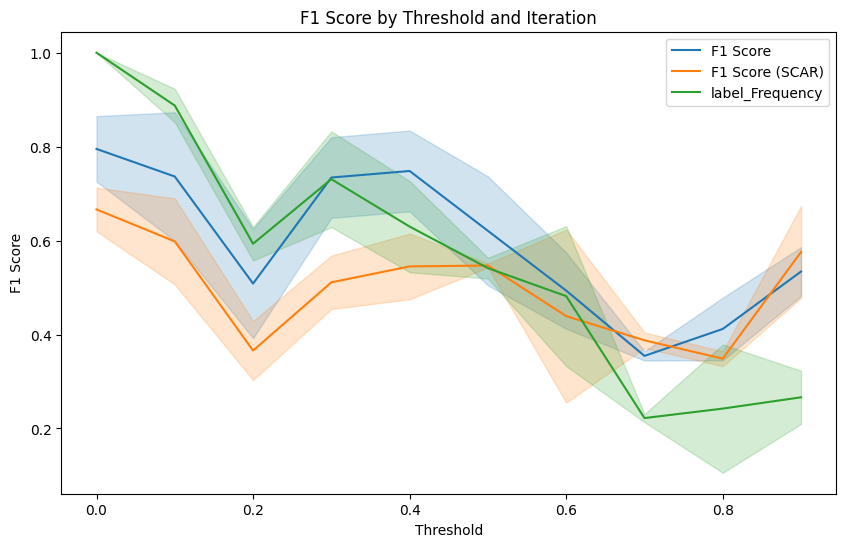

In [89]:
plt.figure(figsize=(10, 6))
# data = results.drop(columns=["feature"]).groupby(["threshold"]).mean().reset_index()
# data_scar = results_scar.drop(columns=["feature"]).groupby(["threshold"]).mean().reset_index()
data = results
data_scar = results_scar
data["f1_diff"] = data_scar["f1"] - data["f1"]
sns.lineplot(data=data, x="threshold", y="f1", palette="viridis", sizes=(20, 200),label="F1 Score")
sns.lineplot(data=data_scar, x="threshold", y="f1", palette="viridis", sizes=(20, 200),label="F1 Score (SCAR)")
sns.lineplot(data=data, x="threshold", y="calculated_c", palette="viridis", sizes=(20, 200),label="label_Frequency")
plt.legend()
plt.title("F1 Score by Threshold and Iteration")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.show()


<Axes: title={'center': 'Label frequency versus SAR'}, xlabel='threshold', ylabel='calculated_c'>

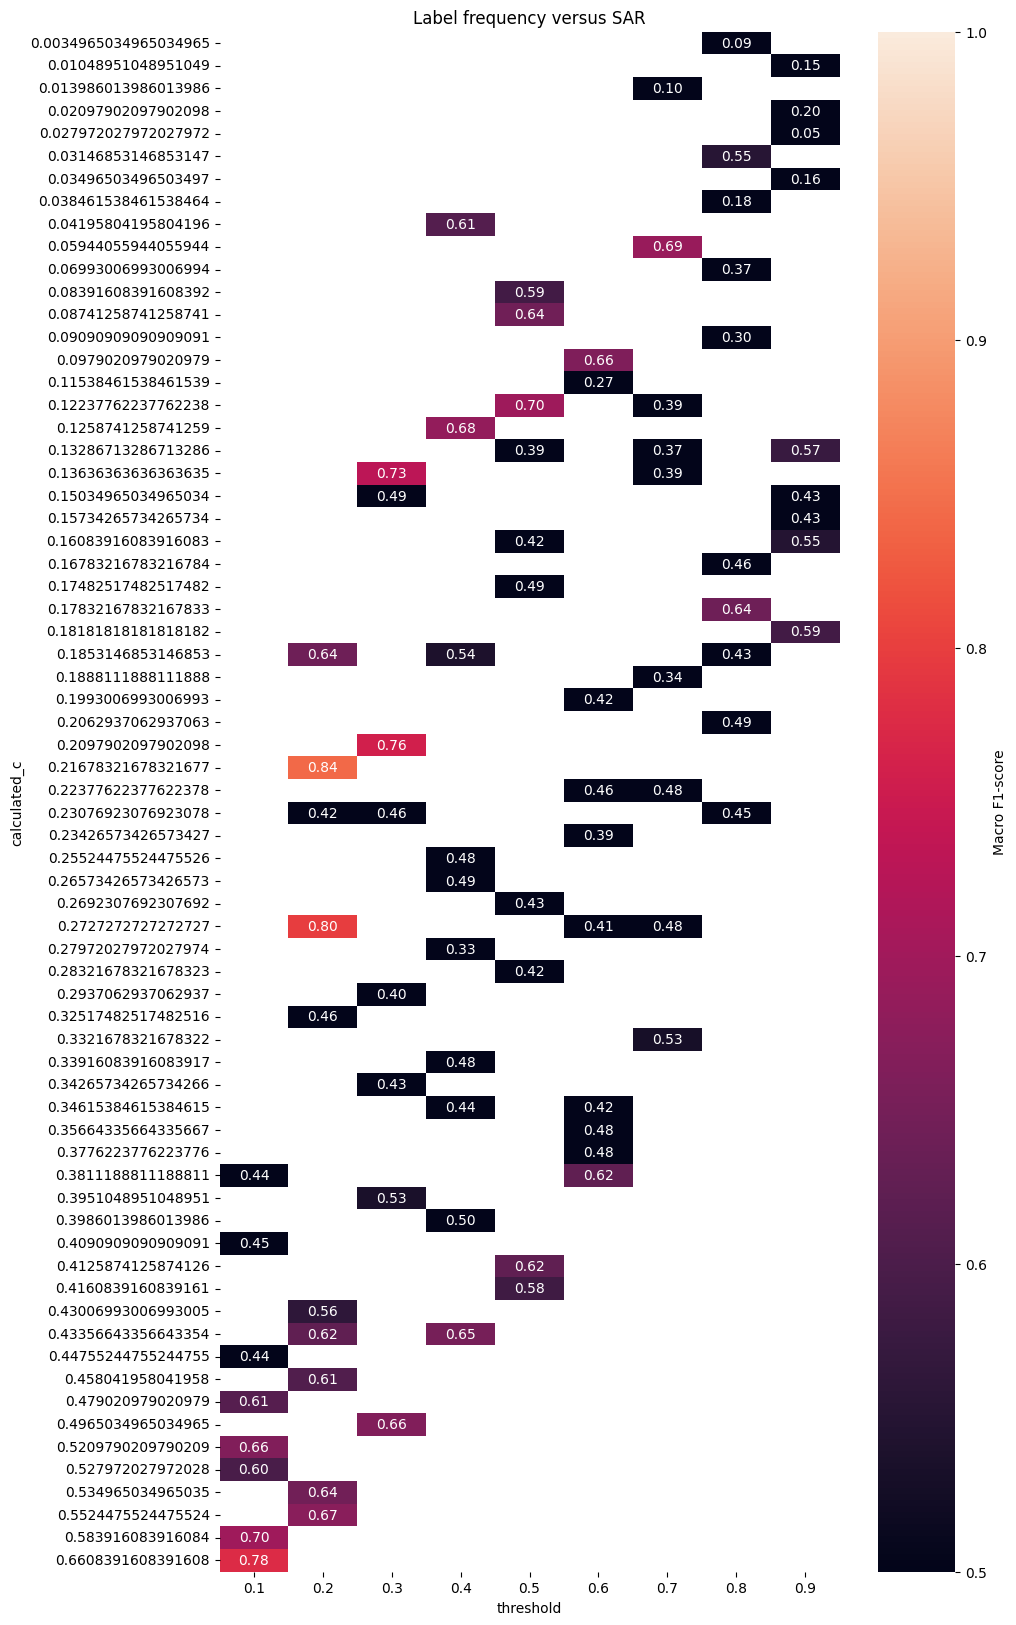

In [13]:
plt.figure(figsize=(10,20))
pivot = results.pivot_table(index="calculated_c", columns="threshold", values="f1")
plt.title(f"Label frequency versus SAR")
sns.heatmap(
    data=pivot,
    annot=True,
    cbar_kws={"label": "Macro F1-score"},
    linewidths=0,
    fmt=".2f",
    vmin=0.5,
    vmax=1
)

In [9]:
data

,threshold,iter,f1,feature,calculated_c,f1_diff
0,0.1,0,0.636713,worst smoothness,0.559441,0.052677
1,0.1,1,0.431590,worst concavity,0.391608,-0.018478
2,0.1,2,0.539439,mean area,0.405594,-0.053373
3,0.1,3,0.645990,worst texture,0.513986,0.034199
4,0.1,4,0.707873,worst smoothness,0.580420,0.017791
...,...,...,...,...,...,...
85,0.9,5,0.270968,worst concave points,0.027972,0.000000
86,0.9,6,0.373527,compactness error,0.153846,-0.102560
87,0.9,7,0.000000,,0.000000,0.000000
88,0.9,8,0.438285,smoothness error,0.255245,-0.136378


In [10]:
data = results.drop(columns=["feature"]).groupby(["threshold",'iter']).mean().reset_index()
data

,threshold,iter,f1,calculated_c,f1_diff
0,0.1,0,0.636713,0.559441,0.052677
1,0.1,1,0.431590,0.391608,-0.018478
2,0.1,2,0.539439,0.405594,-0.053373
3,0.1,3,0.645990,0.513986,0.034199
4,0.1,4,0.707873,0.580420,0.017791
...,...,...,...,...,...
85,0.9,5,0.270968,0.027972,0.000000
86,0.9,6,0.373527,0.153846,-0.102560
87,0.9,7,0.000000,0.000000,0.000000
88,0.9,8,0.438285,0.255245,-0.136378
